In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

In [2]:
milk = pd.read_csv("Datasets/milk.csv", index_col=0)

scaler = StandardScaler().set_output(transform='pandas')
df_scaled = scaler.fit_transform(milk)

In [3]:
Ks = [2,3,4,5]
scores= []
for i in Ks:
    clust = KMeans(n_clusters=i, random_state=26)
    clust.fit(df_scaled)
    scores.append([i, silhouette_score(df_scaled, clust.labels_)])

df_scores = pd.DataFrame(scores, columns=['clusters', 'scores'])
df_scores.sort_values('scores', ascending=False)

,clusters,scores
0,2,0.525851
2,4,0.443481
3,5,0.409260
1,3,0.370679


# PCA

In [4]:
prcomp= PCA().set_output(transform='pandas')
df_scaled = scaler.fit_transform(milk)
pca_data = prcomp.fit_transform(df_scaled)
km = KMeans(n_clusters=2, random_state=26)
km.fit(df_scaled)
pca_data['cluster'] = km.labels_
pca_data['cluster'] = pca_data['cluster'].astype('str')

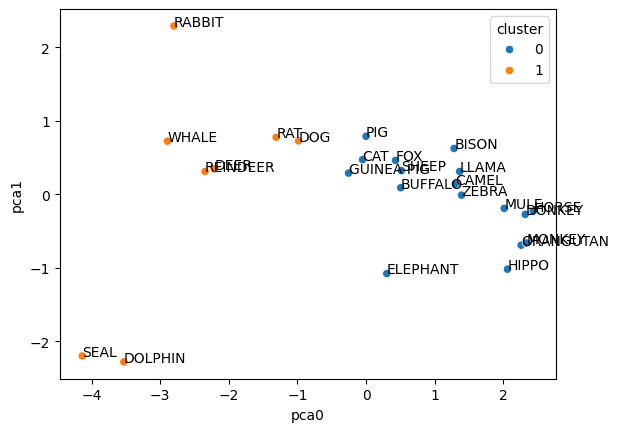

In [6]:
sns.scatterplot(data=pca_data, x="pca0", y="pca1", hue="cluster")
for i in range(0, milk.shape[0]):
    plt.text(x=pca_data['pca0'].values[i], 
             y=pca_data['pca1'].values[i], 
             s=list(milk.index)[i])
plt.show()

## Nutrient Dataset

In [11]:
nut = pd.read_csv("D:/Machine_Learning/Datasets/nutrient.csv", index_col=0)

scaler = StandardScaler().set_output(transform='pandas')
df_scaled = scaler.fit_transform(nut)

In [12]:
Ks = [2,3,4,5]
scores= []
for i in Ks:
    clust = KMeans(n_clusters=i, random_state=26)
    clust.fit(df_scaled)
    scores.append([i, silhouette_score(df_scaled, clust.labels_)])

df_scores = pd.DataFrame(scores, columns=['clusters', 'scores'])
df_scores.sort_values('scores', ascending=False)

,clusters,scores
3,5,0.414230
2,4,0.372094
1,3,0.306160
0,2,0.287596


In [15]:
prcomp= PCA().set_output(transform='pandas')
df_scaled = scaler.fit_transform(nut)
pca_data = prcomp.fit_transform(df_scaled)
km = KMeans(n_clusters=5, random_state=26)
km.fit(df_scaled)
pca_data['cluster'] = km.labels_
pca_data['cluster'] = pca_data['cluster'].astype('str')

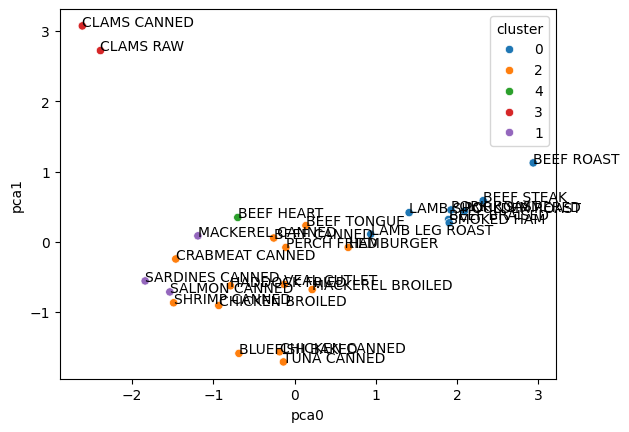

In [16]:
sns.scatterplot(data=pca_data, x="pca0", y="pca1", hue="cluster")
for i in range(0, nut.shape[0]):
    plt.text(x=pca_data['pca0'].values[i], 
             y=pca_data['pca1'].values[i], 
             s=list(nut.index)[i])
plt.show()

# Analyzing Centroids

In [19]:
df = nut.copy()
km = KMeans(n_clusters=5, random_state=26)
km.fit(df_scaled)
df['Cluster'] = km.labels_
df.groupby('Cluster').mean()

,energy,protein,fat,calcium,iron
Cluster,,,,,
0,341.875000,18.750000,28.875000,8.750000,2.437500
1,151.666667,18.333333,7.666667,227.666667,1.666667
2,164.230769,20.307692,7.923077,20.307692,1.730769
3,57.500000,9.000000,1.000000,78.000000,5.700000
4,160.000000,26.000000,5.000000,14.000000,5.900000
